
# Weather Pattern Analysis Using PCA and K-Means Clustering
### Contributors: Usoff Samantar, Matthew Nunez
#### Contributions:

**Usoff**
 - Initial ground work
 - API/Dataframe creation
 - Hypothesis Testing
 - Machine Learning
 - Simulation Testing

**Matthew**
 - Correlation Testing
 - Hypothesis Testing (T Tests)
 - Machine Learning
 - Code Cleanup

**Together**
 - All Conclusions
 - All Summaries
 - All Reviews
 - Formatting and Organization


#### Description:
This project analyzes historical June weather data for Washington, D.C. to determine whether the week of June 8–14, 2026 is representative of typical June weather patterns. Historical weather observations from 2023–2025 were selected to provide a recent baseline that reflects current climate conditions.

To answer this question, we applied several statistical techniques, including summary statistics, Z-scores, hypothesis testing, simulations, and two-sample comparisons. In addition, we used Principal Component Analysis (PCA) to reduce the dimensionality of the weather data and K-Means clustering to identify common historical weather patterns. While multiple weather variables were analyzed, much of the statistical analysis focuses on temperature. Understanding whether a given week reflects typical historical weather helps identify unusual weather events and demonstrates how statistical and machine learning techniques can be applied to real-world climate data.

#### Question:
Is the week of June 8th - June 14th representative of historical June weather in Washington, D.C? 

#### Main Objectives:

- Model the data
  - Calculate the mean **($\mu$)** and standard deviation **($\sigma$)**
  - Graph historical data
- Compare Observed vs Historical Data
  - Calculate Z-scores for each date, and plot the chosen week
- Perform statistical tests to determine the significance of the data
- Simulate possible weeks in June
- Apply Principal Component Analysis (PCA) to reduce the dimensionality of the weather data.
- Use K-Means clustering to identify common historical weather patterns and determine which pattern best matches the observed week.


#### Data Curation

Historical weather data for Washington, D.C. was obtained using the Visual Crossing Weather API for the month of June from 2023 through 2025. These years were selected to provide a recent historical baseline while minimizing the influence of older climate patterns. Weather observations for June 8–14, 2026 were collected separately for comparison.

After importing the data into pandas DataFrames, missing values were removed, dates were converted to datetime objects, and only the relevant weather variables (temperature, humidity, precipitation, and windspeed) were retained. The resulting dataset was then standardized prior to applying Principal Component Analysis (PCA) and K-Means clustering so that each feature contributed equally to the machine learning models.

#### Exploratory Data Analysis

Before applying statistical tests and machine learning techniques, we explored the historical weather data to better understand the distributions and relationships among the selected weather variables. This analysis provides context for the statistical tests and clustering methods used later in the project.


### Imports:

In [21]:
import requests
import pandas as pd
import numpy as np
import math
import matplotlib.pyplot as plt
import scipy
import random
from scipy.stats import norm
from scipy import stats
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from yellowbrick.cluster import KElbowVisualizer

### Visual Crossing API and Dataframe Creation:
#### Resources:
Api info based off of previous work: Youtube Link: https://youtu.be/RPEsS2hzl-Q Time: 1:28-1:53

In [22]:
# Break down and build up string 

url = "https://weather.visualcrossing.com/VisualCrossingWebServices/rest/services/timeline/Washington,DC/"
start_date = "-06-01"
separator = "/"
end_date = "-06-30" 
final_append = "?key="
visual_crossing_API_KEY = "GW4267MR27NGP7JH2XVMMMFGP"
include = "&include=days"
include_elements = "&elements=datetime,address,feelslike,humidity,tempmax,tempmin,temp,precip,windspeed,conditions"
month_list = [requests.get(url + str(x) + start_date + separator + str(x) + end_date + final_append + visual_crossing_API_KEY + include + include_elements) for x in range(2025, 2022, -1)]
data_list = [data.json() for data in month_list]

three_year_dfs = [pd.DataFrame(data['days']) for data in data_list]

# Capitalize Columns and change rows to start at 1 instead of 0 
for x in range(len(three_year_dfs)):
    # Index starts at 1
    three_year_dfs[x].index += 1
    # Capitalize Columns
    three_year_dfs[x].columns = three_year_dfs[x].columns.str.title()

# Display Dataframes for all 3 years 
print("June 2025")
display(three_year_dfs[0])
print("June 2024")
display(three_year_dfs[1])
print("June 2023")
display(three_year_dfs[2])


# Now we have the mean and SD so we can calulate the Z-Score by loading in the past 7 days to see if they fit the mean
seven_day_forecast = requests.get(url + "2026-06-08" + separator + "2026-06-14" + final_append + visual_crossing_API_KEY + include + include_elements)
seven_day_forecast = seven_day_forecast.json()
seven_day_forecast =pd.DataFrame(seven_day_forecast['days'])

# Index starts at 1
seven_day_forecast.index += 1

# Capitalize Columns
seven_day_forecast.columns = seven_day_forecast.columns.str.title()

# Display 7-Day Weather Data
print("7 Day Weather June 8th - June 14th, 2026")
display(seven_day_forecast)


June 2025


,Datetime,Tempmax,Tempmin,Temp,Feelslike,Humidity,Precip,Windspeed,Conditions
1,2025-06-01,69.2,48.7,60.4,60.1,53.0,0.000,16.6,Partially cloudy
2,2025-06-02,74.1,51.6,64.2,64.2,51.5,0.000,11.3,Partially cloudy
3,2025-06-03,80.1,55.7,67.9,67.9,59.6,0.000,9.0,Partially cloudy
4,2025-06-04,84.1,61.8,72.4,72.9,67.6,0.000,13.3,Partially cloudy
5,2025-06-05,83.0,66.8,74.4,75.1,73.2,0.000,12.6,Partially cloudy
6,2025-06-06,83.1,67.5,74.8,75.4,76.9,0.000,9.0,Partially cloudy
7,2025-06-07,85.9,70.0,76.5,76.9,73.5,0.129,11.9,"Rain, Partially cloudy"
8,2025-06-08,75.5,70.0,72.7,72.7,80.3,0.066,11.0,"Rain, Overcast"
9,2025-06-09,82.9,68.0,74.3,74.9,78.4,0.011,12.4,"Rain, Partially cloudy"
10,2025-06-10,84.8,71.9,77.1,77.0,68.5,0.000,14.3,Partially cloudy


June 2024


,Datetime,Tempmax,Tempmin,Temp,Feelslike,Humidity,Precip,Windspeed,Conditions
1,2024-06-01,81.0,58.5,70.4,70.3,49.3,0.000,13.8,Partially cloudy
2,2024-06-02,81.1,64.3,73.1,73.2,61.8,0.000,18.1,Partially cloudy
3,2024-06-03,84.5,70.0,77.5,77.9,64.0,0.011,8.9,"Rain, Partially cloudy"
4,2024-06-04,87.9,69.5,78.8,79.7,67.6,0.000,19.0,Partially cloudy
5,2024-06-05,82.1,71.8,76.2,76.8,82.2,0.425,14.4,"Rain, Overcast"
6,2024-06-06,85.8,74.9,79.7,81.4,73.3,0.000,16.8,Partially cloudy
7,2024-06-07,86.9,72.7,79.3,78.5,45.3,0.000,22.2,Partially cloudy
8,2024-06-08,83.9,64.7,75.9,75.5,41.9,0.000,15.9,Partially cloudy
9,2024-06-09,83.0,70.6,76.7,76.6,45.6,0.000,20.8,Partially cloudy
10,2024-06-10,82.1,64.6,74.3,74.1,43.3,0.000,17.9,Partially cloudy


June 2023


,Datetime,Tempmax,Tempmin,Temp,Feelslike,Humidity,Precip,Windspeed,Conditions
1,2023-06-01,83.6,58.5,72.0,71.9,62.9,0.000,11.0,Clear
2,2023-06-02,92.5,63.3,77.6,77.3,58.6,0.000,9.6,Clear
3,2023-06-03,83.7,62.7,75.3,75.6,64.7,0.000,17.3,Partially cloudy
4,2023-06-04,75.5,60.8,66.6,66.6,62.6,0.000,13.1,Partially cloudy
5,2023-06-05,79.7,58.8,69.4,69.4,57.0,0.000,13.0,Partially cloudy
6,2023-06-06,82.8,60.3,72.6,72.2,41.7,0.000,15.9,Partially cloudy
7,2023-06-07,79.6,62.1,72.0,72.0,41.8,0.000,15.5,Partially cloudy
8,2023-06-08,77.7,60.5,68.7,68.7,48.4,0.000,13.6,Partially cloudy
9,2023-06-09,75.5,59.2,68.3,68.3,46.9,0.000,14.9,Partially cloudy
10,2023-06-10,86.8,58.4,73.1,72.4,46.5,0.000,14.2,Partially cloudy


7 Day Weather June 8th - June 14th, 2026


,Datetime,Tempmax,Tempmin,Temp,Feelslike,Humidity,Precip,Windspeed,Conditions
1,2026-06-08,79.5,68.8,73.9,73.9,58.7,0.000,12.0,Partially cloudy
2,2026-06-09,83.1,63.8,72.7,72.7,55.1,0.000,12.3,Partially cloudy
3,2026-06-10,89.1,71.2,77.6,79.1,76.1,0.098,13.5,"Rain, Overcast"
4,2026-06-11,96.9,73.2,83.9,87.5,69.3,0.004,13.1,Partially cloudy
5,2026-06-12,97.9,71.9,81.7,84.7,71.9,0.111,19.7,"Rain, Partially cloudy"
6,2026-06-13,89.9,71.9,81.3,80.9,55.6,0.000,13.4,Partially cloudy
7,2026-06-14,93.6,72.2,82.1,84.1,63.7,0.010,22.1,Partially cloudy


### Functions for Hypothesis Testing:

In [23]:
def display_content(label: str, x_axis: str, points_color="orange") -> tuple[float,...]: # Return tuple of floats for mean used in Hypothesis Testing Function

    mean = 0
    standard_deviation = 0
    square = lambda x: x ** 2

    # Find the mean
    for x in range(len(three_year_dfs)):
        mean += three_year_dfs[x][label].mean()
        if x == len(three_year_dfs) - 1:
            mean = mean / len(three_year_dfs) 
    
    # Find the Standard Deviation 
    for index in range(len(three_year_dfs)):
        for item in three_year_dfs[index][label]:
            standard_deviation += square((item - mean))
    
    standard_deviation = math.sqrt(standard_deviation / (len(three_year_dfs[0]) + len(three_year_dfs[1]) + len(three_year_dfs[2]) - 1)) # n - 1: for sample standard deviation since we are using a sample of the total June months ever
    
    formatted_labels = {
        "Humidity":"Humidity",
        "Temp":"Temperature",
        "Tempmax":"Max Temperature",
        "Tempmin":"Min Temperature",
        "Feelslike":"Feels Like",
        "Precip":"Precipitation",
        "Windspeed":"Windspeed",
    }
    formatted_label = formatted_labels.get(label)
    z_scores = []

    for val in seven_day_forecast[label]:
        z_scores.append((val - mean) / standard_deviation)
    
    seven_day_forecast[f'{label} Z-Score'] = z_scores
    
    # Spaceing Lines: Utilize a 1000 x values to calculate the normal distribution density: 
    # The bell shaped curve   
    x = np.linspace(mean - (4 * standard_deviation), mean + (4 * standard_deviation), 1000)
    
    y = norm.pdf(x, mean, standard_deviation)
    
    # Start of plot 
    plt.figure(figsize=(12, 8))
    plt.plot(x,y, label="Histroical June Distribution")
    
    # Mean Line
    plt.axvline(mean,color="orange", linestyle="-", linewidth=2, label="Mean")
    
    # Mean Temperature Line
    plt.text(mean, min(y) * .9, f"{round(mean,1)}\n Mean {formatted_label}", rotation = 0, ha = 'center')
    
    for z in [-3, -2, -1, 1, 2, 3]:
        pcnt = ""
        if z % 3 == 0:
            pcnt = "99.7%"
        elif z % 2 == 0:
            pcnt = "95%"
        else:
            pcnt = "68%"
        plt.axvline(mean + z * standard_deviation, color='blue', linestyle="--", alpha = .5)
        plt.text(mean + z * standard_deviation, max(y) * .8, f"{z}σ = ({pcnt})", rotation = 90, ha = 'center')
    
    # label_list
    label_list = seven_day_forecast[label]
    
    # Where each point will be located on the curve 
    points = norm.pdf(label_list, mean, standard_deviation)
    
    plt.plot(label_list, points, '-o', color=points_color, label=f'June 8th - 14th {formatted_label}')
    
    plt.xlabel(x_axis)
    plt.ylabel("Probability Density")
    plt.title(f"Week of June 8th - June 14th {formatted_label} vs Historical Samples")
    plt.legend()
    plt.show()
    print(f"{formatted_labels.get(label)} Table for the Week June 8th - 14th")
    display(seven_day_forecast[['Datetime',label,f'{label} Z-Score']])
    return (float(mean), float(standard_deviation))


# Function for hypothesis testing
def hypothesis_test(label:str, mean:float, std:float, alpha:float):

    print(f"""Two-tail Z-Test:\nHypothesis Testing for {label} with Alpha = {alpha}:\n 
    - Null Hypothesis H₀:  M₀ = Avg = The average {label} during the week June 8th - 14th, 2026 is equal to the historical June average.\n
    - Alternative Hypothesis 𝐻a:  M₀ ≠ Avg =  The average {label} during the week June 8th - 14th, 2026 is different from the historical June average.\n""")
    
    square_root = lambda x: math.sqrt(x)
    week_data = seven_day_forecast[label]
    week_mean = week_data.mean()
    n = len(week_data)
    
    # Standard error and Z-Statistic Calulation
    stderror = std / square_root(n)
    z_statictic = (week_mean - mean) / stderror

    # Two-tail test 2 * P(Z >= |Z-Statistic|) = 2 * (1 - P(|Z-Statistic|))
    p_value = 2 * (1 - norm.cdf(abs(z_statictic)))

    print(f"Week Mean: {round(week_data.mean(),2)}")
    print(f"Historical Mean: {round(mean,2)}")
    print(f"Z Statistic: {round(z_statictic,4)}")
    print(f"P-Value: {round(p_value,4)}\n")

    if p_value > alpha:
        print("Based off the Z-test, there is no significant difference between the historical June data and our week sample.")
        print("Fail to reject H₀\n")

    else:
        print("Based off the Z-test, there is significant differences between the historical June data and our week sample.")
        print("Reject H₀\n")

def hypothesis_tests_two_tailed_t(label: str, mean: float, alpha:float):

    print(f"""Two-tail T-Test with sigma unknown:\nHypothesis Testing for {label} with Alpha = {alpha}:\n 
    - Null Hypothesis H₀:  M₀ = Avg = The average {label} during the week June 8th - 14th, 2026 is equal to the historical June average.\n
    - Alternative Hypothesis 𝐻a:  M₀ ≠ Avg =  The average {label} during the week June 8th - 14th, 2026 is different from the historical June average.\n""")
    
    week_data = seven_day_forecast[label]

    # Sigma is calculated from the 7-day sample June 8th - June 14th
    resp = stats.ttest_1samp(week_data, popmean=mean, alternative="two-sided")
    
    print(f"Week Mean: {round(week_data.mean(), 2)}")
    print(f"Historical Mean: {round(mean, 2)}")
    print(f"T Statistic: {round(resp.statistic, 4)}")
    print(f"P-Value: {round(resp.pvalue, 4)}\n")
    
    if resp.pvalue > alpha:
        print(f"Based off the two-tailed T-test, there is no significant evidence that the week's average {label} differs from the historical June average.")
        print("Fail to reject H₀\n")
    else:
        print(f"Based off the two-tailed T-test, there is significant evidence that the week's average {label} differs from the historical June average.")
        print("Reject H₀\n")

def hypothesis_tests_left_t(label: str, mean: float, alpha:float):

    print(f"""One-tail T-Test with sigma unknown:\nHypothesis Testing for {label} with Alpha = {alpha}:\n 
    - Null Hypothesis H₀:  M₀ >= Avg where the average {label} during the week June 8th - 14th, 2026 is greater than or equal to the historical June average.\n
    - Alternative Hypothesis 𝐻a:  M₀ < Avg where the average {label} during the week June 8th - 14th, 2026 is less than the historical June average.\n""")
    
    week_data = seven_day_forecast[label]

    # Sigma is calculated from the 7-day sample June 8th - June 14th
    resp = stats.ttest_1samp(week_data, popmean=mean, alternative="less")
    
    print(f"Week Mean: {round(week_data.mean(), 2)}")
    print(f"Historical Mean: {round(mean, 2)}")
    print(f"T Statistic: {round(resp.statistic, 4)}")
    print(f"P-Value: {round(resp.pvalue, 4)}\n")
    
    if resp.pvalue > alpha:
        print(f"Based off the left-tailed T-test, there is no significant evidence that the week's average {label} is less than the historical June average.")
        print("Fail to reject H₀\n")
    else:
        print(f"Based off the left-tailed T-test, there is significant evidence that the week's average {label} is less than the historical June average.")
        print("Reject H₀\n")


def hypothesis_tests_two_sample_t(label:str, historical_df, week_df, alpha: float):

    print(f"""Two-sample T-Test with sigma unknown:\nHypothesis Testing for {label} with Alpha = {alpha}:\n 
    - Null Hypothesis H₀:  Sample mean = Historical mean where the average {label} during the week June 8th - 14th, 2026 is equal to the historical June average.\n
    - Alternative Hypothesis 𝐻a: Sample mean ≠ Historical mean where the average {label} during the week June 8th - 14th, 2026 is not equal to the historical June average.\n""")
    
    combined = []

    # Combine dataframes 
    for x in range(1, len(historical_df), 1):
        if x == 1:
            combined = pd.concat([historical_df[0][label], historical_df[x][label]], ignore_index= True)
        else:
            combined = pd.concat([combined, historical_df[x][label]],ignore_index= True)

    week_vector = week_df[label]

    # We cannot assume the variance are the same, in fact we know they are not.
    data = stats.ttest_ind(combined, week_vector, equal_var=False)

    print(f"Week Mean: {round(week_vector.mean(), 2)}")
    print(f"Historical Mean: {round(combined.mean(), 2)}")
    print(f"T Statistic: {round(data.statistic, 4)}")
    print(f"P Value: {round(data.pvalue, 4)}\n")

    if data.pvalue > alpha:
        print(f"Based off the two-tailed t-test, there is no significant evidence that the weeks sample data and the historical June {label} data have different means.")
        print("Fail to reject H0\n")
    else:
        print(f"Based off the two-tailed t-test, there is significant evidence that the weeks sample data and the historical June {label} data have different means.")
        print("Reject H0\n")


### Normal Distribution, Data Output, and Hypothesis Testing:
- This section looks at whether the observed weather during the week of June 8th - June 14th, 2026 differs significantly from the historical June weather data collected from 2023 - 2025.

- Four hypothesis tests are performed for each weather attribute in our Dataframe:

   - 1. Two-tailed Z-Test
      - Note: A two-tailed Z-Test tells us if our test week June 8th - June 14th 2026 is significantly different from our historical averages determined by our specified $\alpha$ level. 
   - 2. Two-tailed T-Test
   - 3. One-tailed T-Test

   - 4. Two-sample T-Test
      - Lastly we will compare our historical data and our 7-day sample using a two-sample T-Test assumming each has a different variance.

#### Notes:

   - Null Hypothesis H₀:  M₀ = Avg = The average attribute during the week June 8th - 14th, 2026 is equal to the historical June average.     
   - Alternative Hypothesis 𝐻a:  M₀ ≠ Avg =  The average attribute during the week June 8th - 14th, 2026 is different from the historical June average.
   - We have used the 2 functons to calculate a 3-year historical distribution by calulating the mean, **($\mu$)** and standard deviation **($\sigma$)** utilizing all days in June 2023 - June 2025 inclusive.
   - The Z-Score indicates how many standard deviations the daily attribute is away from the three-year historical mean.
   - We set $\alpha$ level to $\alpha$ = 0.05. This can be changed if needed.

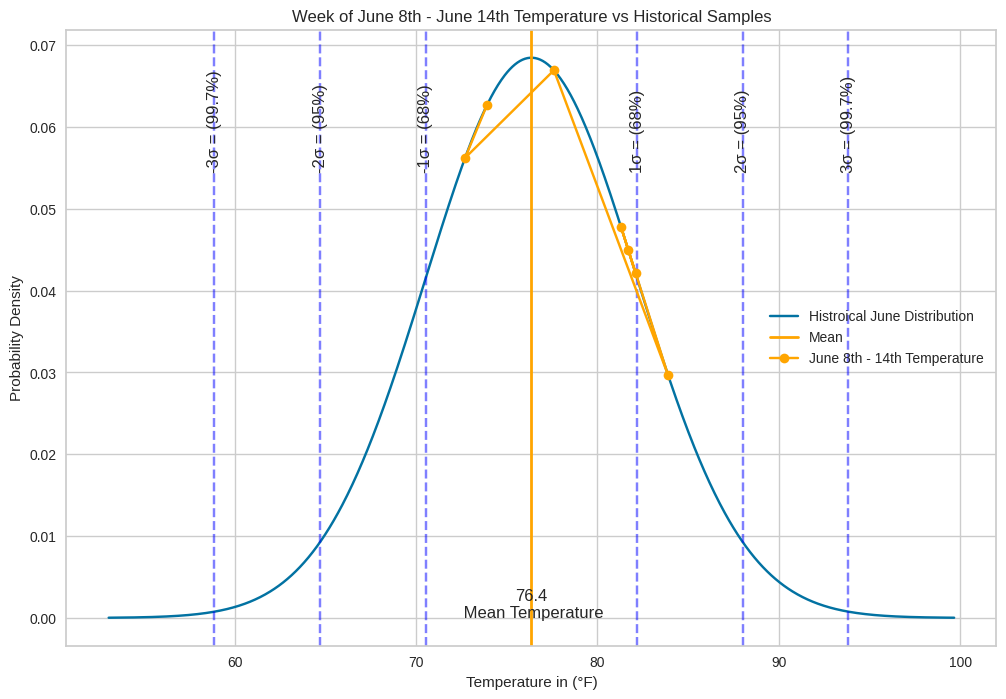

Temperature Table for the Week June 8th - 14th


,Datetime,Temp,Temp Z-Score
1,2026-06-08,73.9,-0.421965
2,2026-06-09,72.7,-0.627895
3,2026-06-10,77.6,0.212985
4,2026-06-11,83.9,1.294116
5,2026-06-12,81.7,0.916578
6,2026-06-13,81.3,0.847935
7,2026-06-14,82.1,0.985221


Two-tail Z-Test:
Hypothesis Testing for Temp with Alpha = 0.05:
 
    - Null Hypothesis H₀:  M₀ = Avg = The average Temp during the week June 8th - 14th, 2026 is equal to the historical June average.

    - Alternative Hypothesis 𝐻a:  M₀ ≠ Avg =  The average Temp during the week June 8th - 14th, 2026 is different from the historical June average.

Week Mean: 79.03
Historical Mean: 76.36
Z Statistic: 1.2121
P-Value: 0.2255

Based off the Z-test, there is no significant difference between the historical June data and our week sample.
Fail to reject H₀



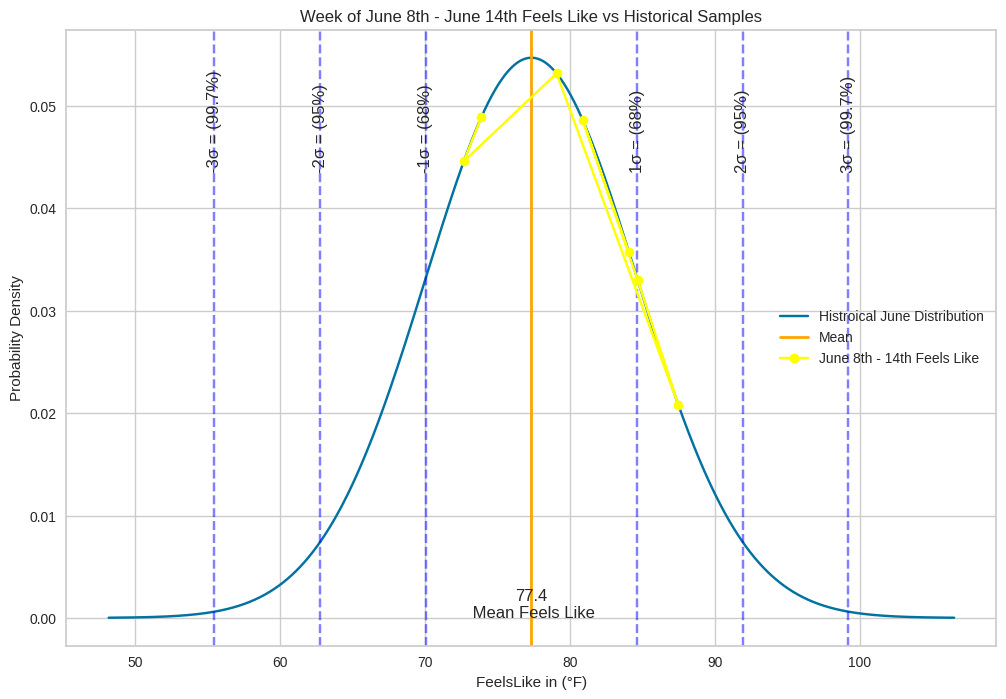

Feels Like Table for the Week June 8th - 14th


,Datetime,Feelslike,Feelslike Z-Score
1,2026-06-08,73.9,-0.474842
2,2026-06-09,72.7,-0.639421
3,2026-06-10,79.1,0.238335
4,2026-06-11,87.5,1.390391
5,2026-06-12,84.7,1.006372
6,2026-06-13,80.9,0.485204
7,2026-06-14,84.1,0.924083


Two-tail Z-Test:
Hypothesis Testing for Feelslike with Alpha = 0.05:
 
    - Null Hypothesis H₀:  M₀ = Avg = The average Feelslike during the week June 8th - 14th, 2026 is equal to the historical June average.

    - Alternative Hypothesis 𝐻a:  M₀ ≠ Avg =  The average Feelslike during the week June 8th - 14th, 2026 is different from the historical June average.

Week Mean: 80.41
Historical Mean: 77.36
Z Statistic: 1.1075
P-Value: 0.2681

Based off the Z-test, there is no significant difference between the historical June data and our week sample.
Fail to reject H₀



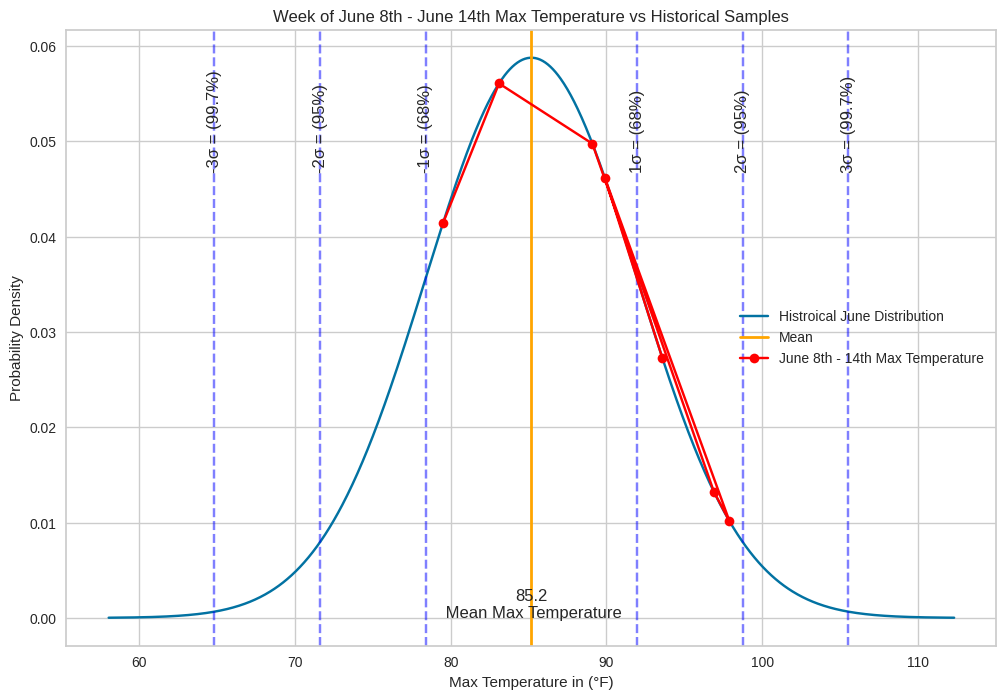

Max Temperature Table for the Week June 8th - 14th


,Datetime,Tempmax,Tempmax Z-Score
1,2026-06-08,79.5,-0.836940
2,2026-06-09,83.1,-0.306589
3,2026-06-10,89.1,0.577330
4,2026-06-11,96.9,1.726423
5,2026-06-12,97.9,1.873743
6,2026-06-13,89.9,0.695185
7,2026-06-14,93.6,1.240268


Two-tail Z-Test:
Hypothesis Testing for Tempmax with Alpha = 0.05:
 
    - Null Hypothesis H₀:  M₀ = Avg = The average Tempmax during the week June 8th - 14th, 2026 is equal to the historical June average.

    - Alternative Hypothesis 𝐻a:  M₀ ≠ Avg =  The average Tempmax during the week June 8th - 14th, 2026 is different from the historical June average.

Week Mean: 90.0
Historical Mean: 85.18
Z Statistic: 1.8783
P-Value: 0.0603

Based off the Z-test, there is no significant difference between the historical June data and our week sample.
Fail to reject H₀



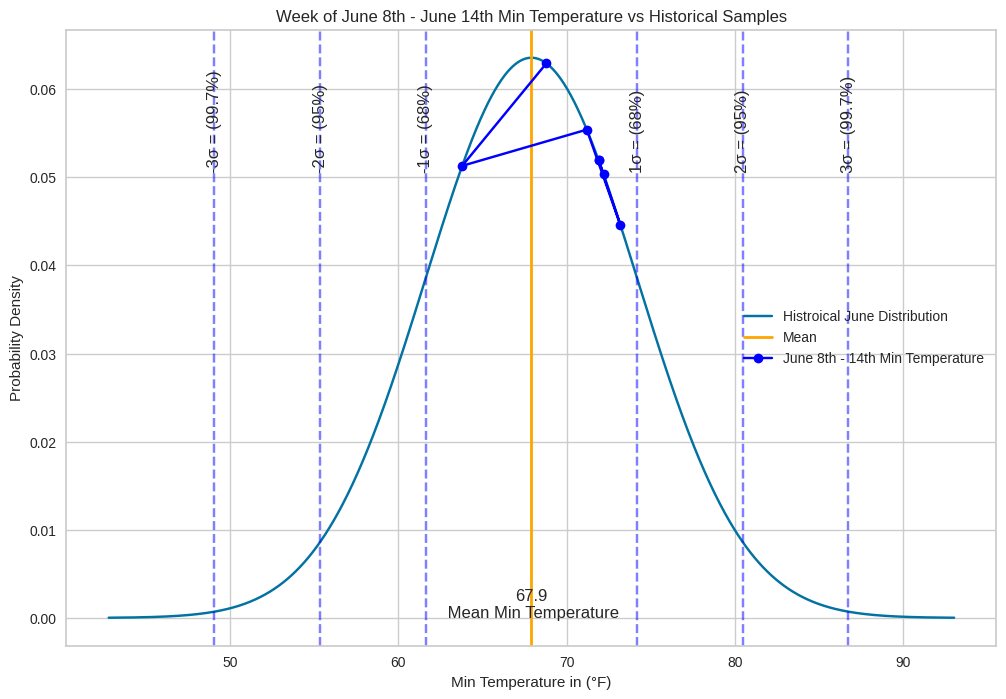

Min Temperature Table for the Week June 8th - 14th


,Datetime,Tempmin,Tempmin Z-Score
1,2026-06-08,68.8,0.141805
2,2026-06-09,63.8,-0.654852
3,2026-06-10,71.2,0.524200
4,2026-06-11,73.2,0.842863
5,2026-06-12,71.9,0.635732
6,2026-06-13,71.9,0.635732
7,2026-06-14,72.2,0.683532


Two-tail Z-Test:
Hypothesis Testing for Tempmin with Alpha = 0.05:
 
    - Null Hypothesis H₀:  M₀ = Avg = The average Tempmin during the week June 8th - 14th, 2026 is equal to the historical June average.

    - Alternative Hypothesis 𝐻a:  M₀ ≠ Avg =  The average Tempmin during the week June 8th - 14th, 2026 is different from the historical June average.

Week Mean: 70.43
Historical Mean: 67.91
Z Statistic: 1.0617
P-Value: 0.2884

Based off the Z-test, there is no significant difference between the historical June data and our week sample.
Fail to reject H₀



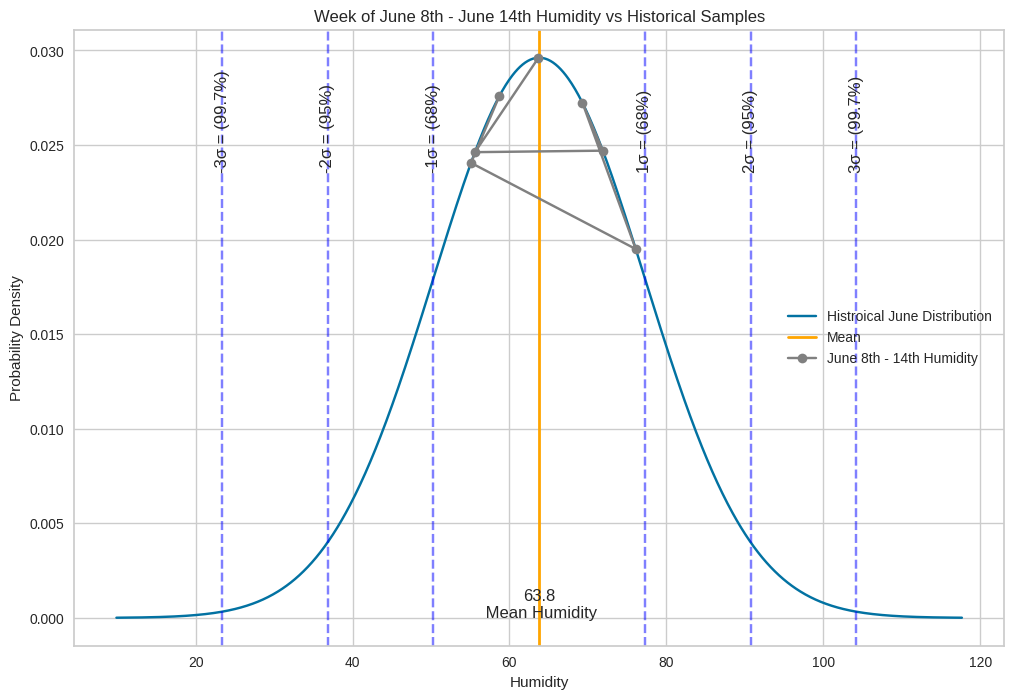

Humidity Table for the Week June 8th - 14th


,Datetime,Humidity,Humidity Z-Score
1,2026-06-08,58.7,-0.377534
2,2026-06-09,55.1,-0.644786
3,2026-06-10,76.1,0.914182
4,2026-06-11,69.3,0.409373
5,2026-06-12,71.9,0.602388
6,2026-06-13,55.6,-0.607667
7,2026-06-14,63.7,-0.006351


Two-tail Z-Test:
Hypothesis Testing for Humidity with Alpha = 0.05:
 
    - Null Hypothesis H₀:  M₀ = Avg = The average Humidity during the week June 8th - 14th, 2026 is equal to the historical June average.

    - Alternative Hypothesis 𝐻a:  M₀ ≠ Avg =  The average Humidity during the week June 8th - 14th, 2026 is different from the historical June average.

Week Mean: 64.34
Historical Mean: 63.79
Z Statistic: 0.1095
P-Value: 0.9128

Based off the Z-test, there is no significant difference between the historical June data and our week sample.
Fail to reject H₀



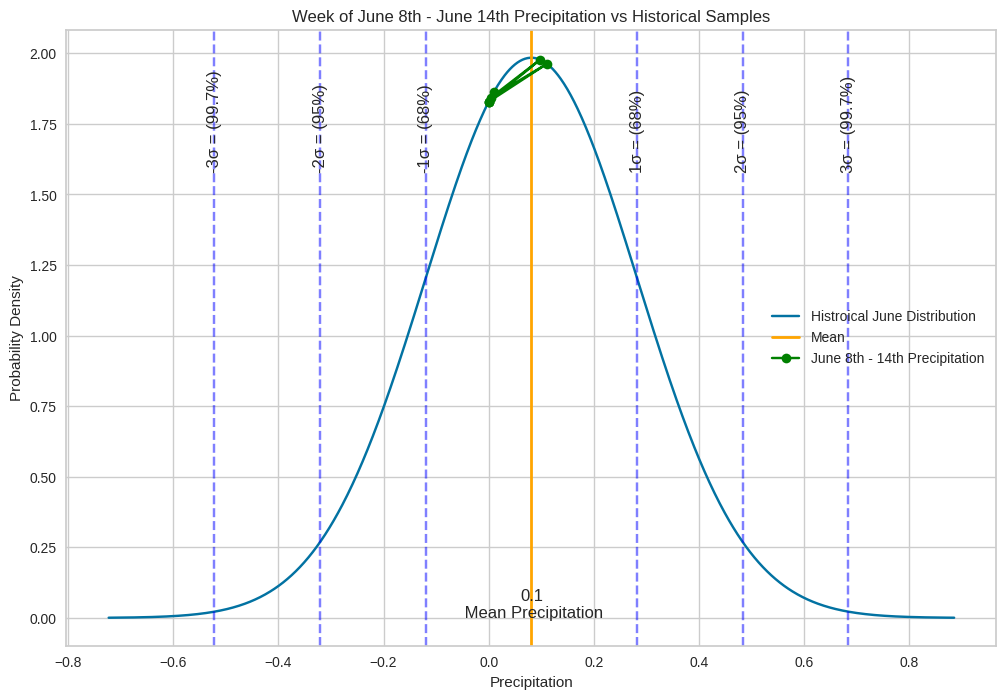

Precipitation Table for the Week June 8th - 14th


,Datetime,Precip,Precip Z-Score
1,2026-06-08,0.000,-0.404666
2,2026-06-09,0.000,-0.404666
3,2026-06-10,0.098,0.082724
4,2026-06-11,0.004,-0.384772
5,2026-06-12,0.111,0.147377
6,2026-06-13,0.000,-0.404666
7,2026-06-14,0.010,-0.354932


Two-tail Z-Test:
Hypothesis Testing for Precip with Alpha = 0.05:
 
    - Null Hypothesis H₀:  M₀ = Avg = The average Precip during the week June 8th - 14th, 2026 is equal to the historical June average.

    - Alternative Hypothesis 𝐻a:  M₀ ≠ Avg =  The average Precip during the week June 8th - 14th, 2026 is different from the historical June average.

Week Mean: 0.03
Historical Mean: 0.08
Z Statistic: -0.6515
P-Value: 0.5147

Based off the Z-test, there is no significant difference between the historical June data and our week sample.
Fail to reject H₀

Two-tail T-Test with sigma unknown:
Hypothesis Testing for Temp with Alpha = 0.05:
 
    - Null Hypothesis H₀:  M₀ = Avg = The average Temp during the week June 8th - 14th, 2026 is equal to the historical June average.

    - Alternative Hypothesis 𝐻a:  M₀ ≠ Avg =  The average Temp during the week June 8th - 14th, 2026 is different from the historical June average.

Week Mean: 79.03
Historical Mean: 76.36
T Statistic: 1.6215
P-Value: 

In [24]:
(mu, sigma) = display_content("Temp", "Temperature in (°F)", "orange")
hypothesis_test("Temp",mu, sigma, .05)
hypothesis_test("Feelslike",*display_content("Feelslike", "FeelsLike in (°F)", "yellow"), .05)
hypothesis_test("Tempmax",*display_content("Tempmax", "Max Temperature in (°F)", "red"), .05)
hypothesis_test("Tempmin",*display_content("Tempmin", "Min Temperature in (°F)", "blue"), .05)
hypothesis_test("Humidity",*display_content("Humidity", "Humidity", "gray"), .05)
hypothesis_test("Precip",*display_content("Precip", "Precipitation", "green"), .05)
hypothesis_tests_two_tailed_t("Temp", mu, 0.05)
hypothesis_tests_left_t("Temp", mu, 0.05)
# Passing in dataframes directly into functionn 
hypothesis_tests_two_sample_t("Temp", three_year_dfs, seven_day_forecast, 0.05)




### Correlation Testing Function
Is temperature related to humidity, precipitation, or windspeed? This section will compare weather variables and determine whether they are linearly related to each other.

#### Variables in question:
- Humidity
- Precipitation
- Windspeed
- Temperature

To measure said relationships, we calculate the correlation value of the two fields to indicate a strong positive (correlation = 1), strong negative (correlation = -1), or any correlation between these values, giving us a range from -1 to 1.
- correlation = 1 -> Represents a strong positive association (They both increase together)
- correlation = -1 -> Represents a strong negative association (As one increases, the other will decrease)
- correlation = 0 -> Represents no linear association between these two fields. (Zero association from one another)

With each pair of data, we created a scatter plot to visually represent our data, and provided a line of best fit to help visualize the overall linear trend between the two variables.

In [25]:
combined_df = pd.concat(three_year_dfs, ignore_index=True)

def correlation_of_fields(field1:str, field2:str):
    correlation = combined_df[field1].corr(combined_df[field2])
    

    formatted_fields = {
        "Humidity":"Humidity",
        "Temp":"Temperature",
        "Tempmax":"Max Temperature",
        "Tempmin":"Min Temperature",
        "Feelslike":"Feels Like",
        "Precip":"Precipitation",
        "Windspeed":"Windspeed",
    }
    formatted_field1 = formatted_fields[field1]
    formatted_field2 = formatted_fields[field2]
    
    x = combined_df[field1]
    y = combined_df[field2]
    m, b = np.polyfit(x,y,1)
    plt.figure(figsize=(12, 8))
    title = f"{formatted_field1} vs {formatted_field2}"
    plt.scatter(x,y)
    plt.plot(x, m*x + b, color="red")
    plt.xlabel(formatted_field1)
    plt.ylabel(formatted_field2)
    plt.title(title)
    plt.show()
    print(f"Correlation for {title}: {correlation}\n")
    
    correlation_msg = ""
    if correlation >= 0.8:
        print(f"There is a very strong positive correlation between {title}")
    elif correlation >= 0.6:
        print(f"There is a strong positive correlation between {title}")
    elif correlation >= 0.4:
        print(f"There is a moderately positive correlation between {title}")
    elif correlation >= 0.2:
        print(f"There is a weak positive correlation between {title}")    
    elif correlation < 0.2 and correlation >= -0.2:
        print(f"There is little to no correlation between {title}")
    elif correlation <= -0.2:
        print(f"There is a weak negative correlation between {title}")
    elif correlation <= -0.4:
        print(f"There is a moderately negative correlation between {title}")
    elif correlation <= -0.6:
        print(f"There is a strong negative correlation between {title}")
    elif correlation <= -0.8:
        print(f"There is a very strong negative correlation between {title}")


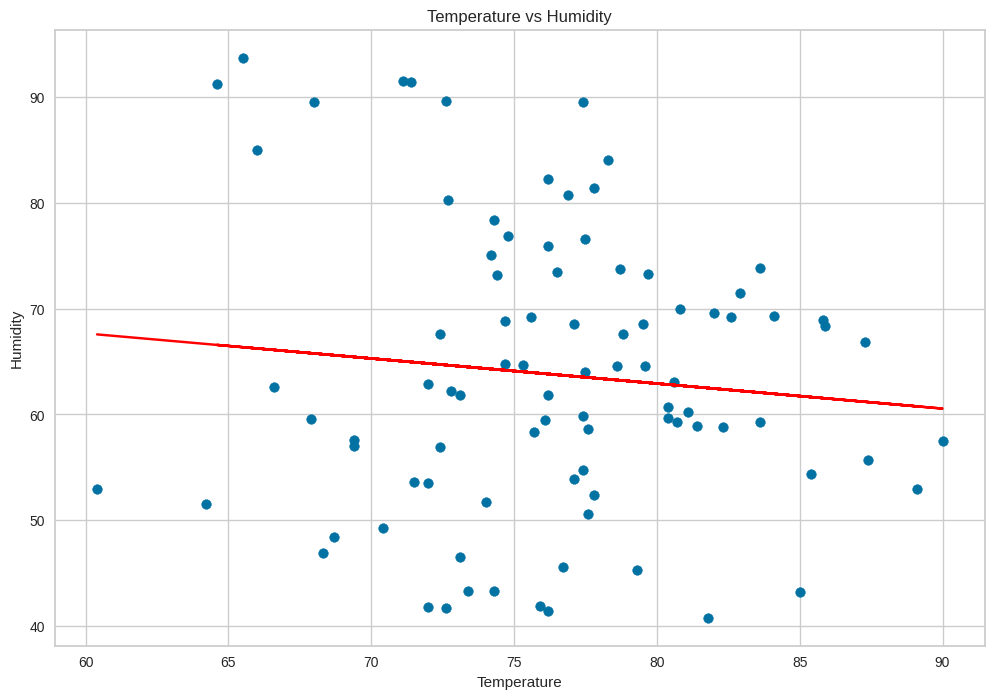

Correlation for Temperature vs Humidity: -0.10243828252397418

There is little to no correlation between Temperature vs Humidity


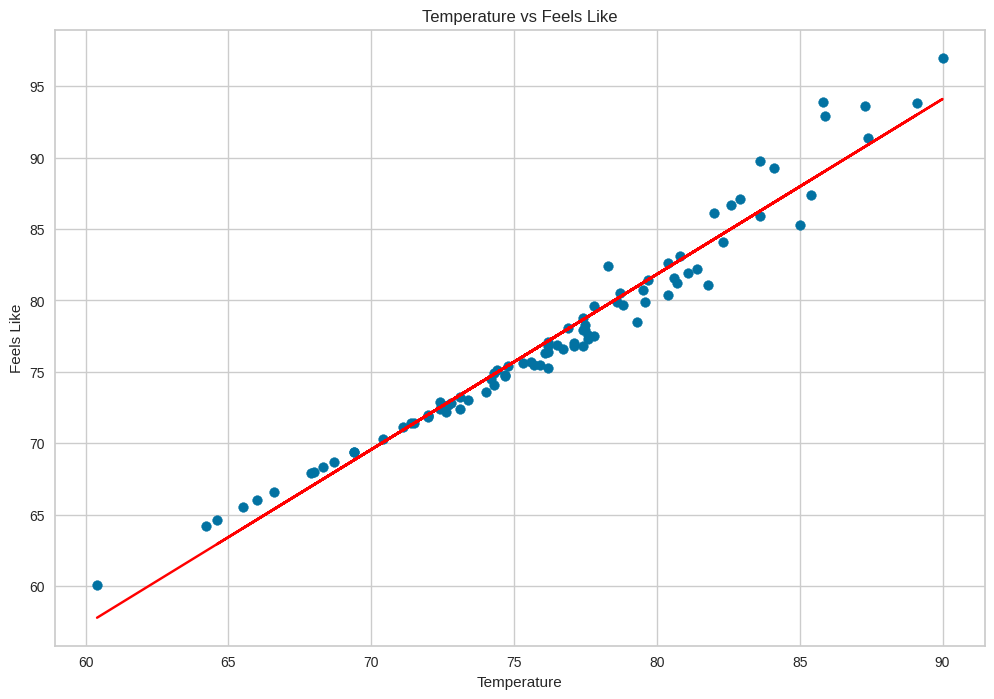

Correlation for Temperature vs Feels Like: 0.9809949216765834

There is a very strong positive correlation between Temperature vs Feels Like


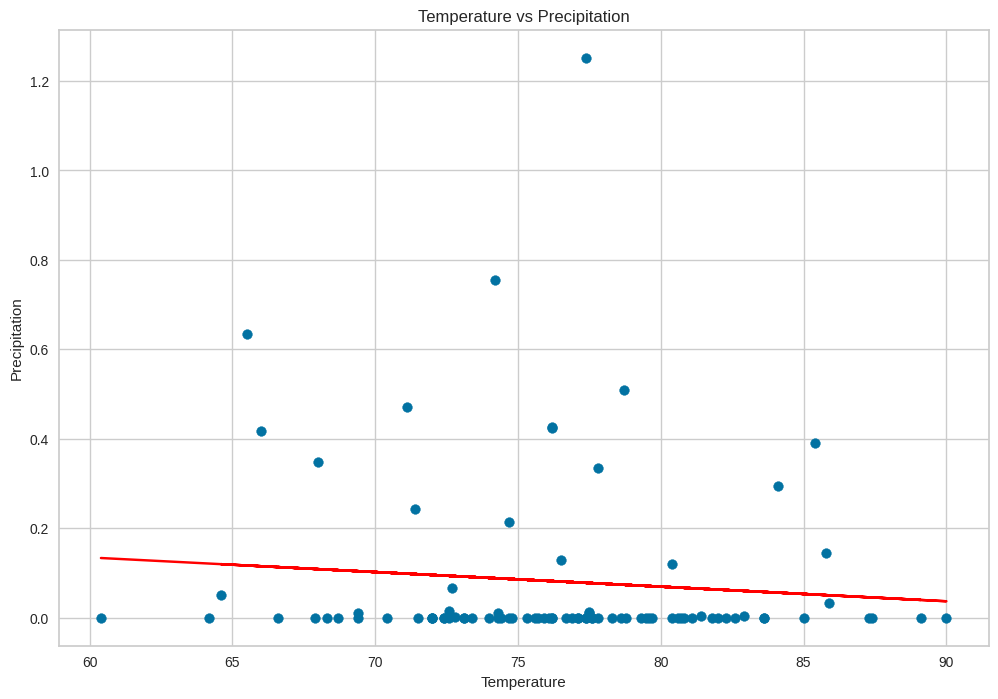

Correlation for Temperature vs Precipitation: -0.09464818338957835

There is little to no correlation between Temperature vs Precipitation


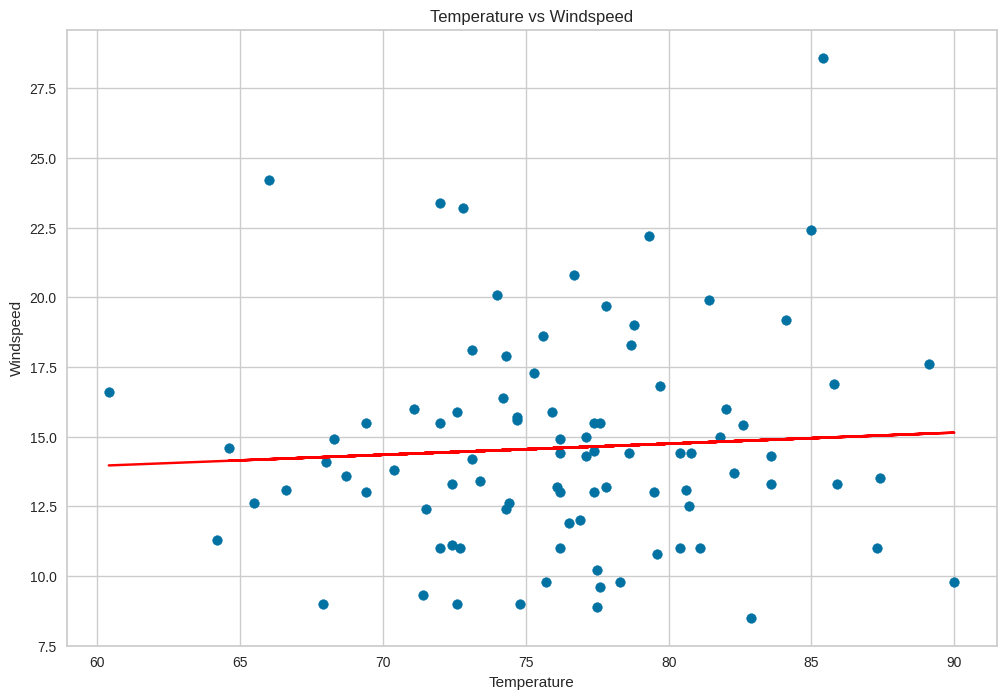

Correlation for Temperature vs Windspeed: 0.06044233658729501

There is little to no correlation between Temperature vs Windspeed


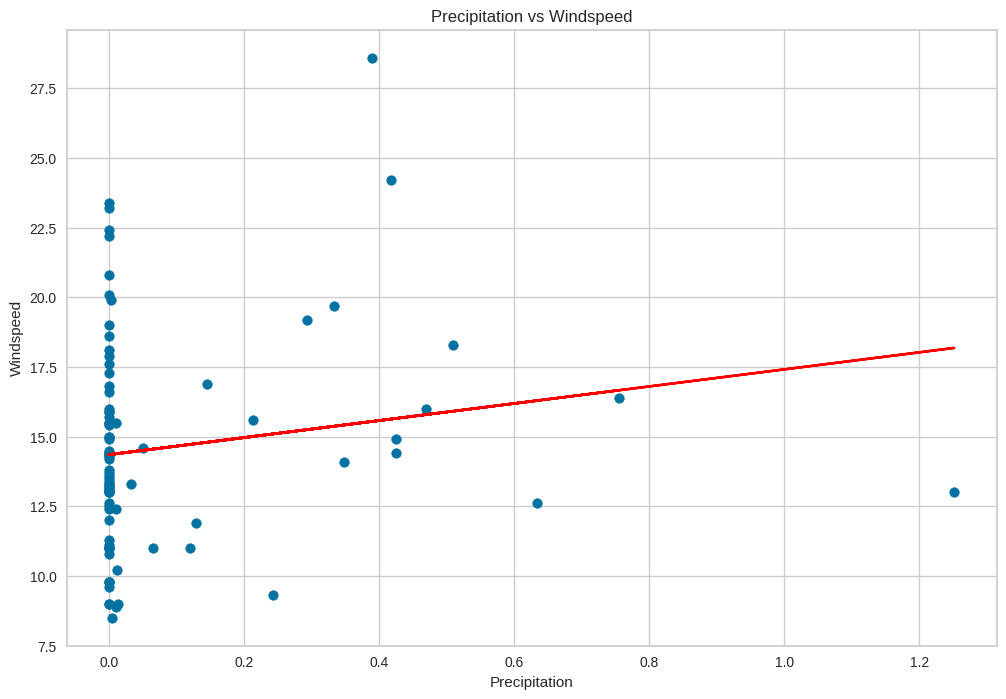

Correlation for Precipitation vs Windspeed: 0.1605101108906085

There is little to no correlation between Precipitation vs Windspeed


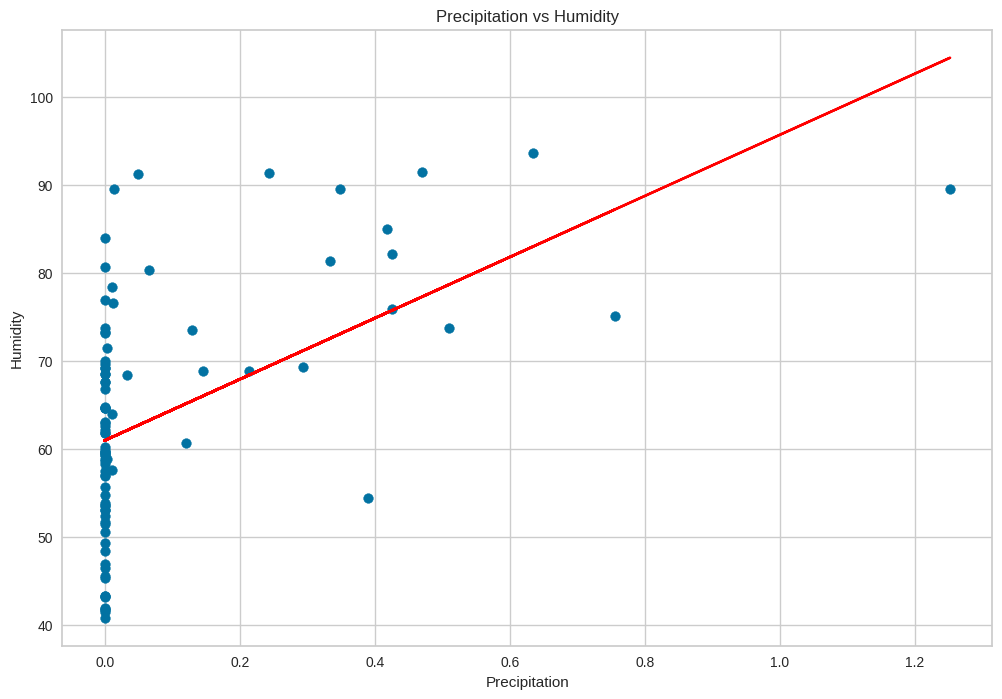

Correlation for Precipitation vs Humidity: 0.5188689030258202

There is a moderately positive correlation between Precipitation vs Humidity


In [26]:
#fields = ["Humidity", "Feelslike", "Precip", "Tempmax", "Tempmin", "Windspeed","Temp"]

correlation_of_fields("Temp", "Humidity")
correlation_of_fields("Temp", "Feelslike")
correlation_of_fields("Temp", "Precip")
correlation_of_fields("Temp", "Windspeed")
correlation_of_fields("Precip", "Windspeed")
correlation_of_fields("Precip", "Humidity")


### Simulation Testing

#### Objective:
Our goal is to simulate 1000 temperatures per day (1000 temps * 7 days a week = 7000) using the normal distribution where we use the mean and historical standard deviation to generate random samples which are normally distributed to model historical distributions.

We did this so that we could visualize various possible weeks in June to determine if our test week is consistent. By visualizing this, we can determine where the observed week falls compared to the simulated data. If the observed week falls within the simulated weeks generated, it suggests that the observed dates temperatures are consistent with the historical June data. 

#### Resources:
- Simulation based on previous work done in STAT422 Probability models "Poisson Processes" Youtube link: https://youtu.be/uTuHhRkB8Xo

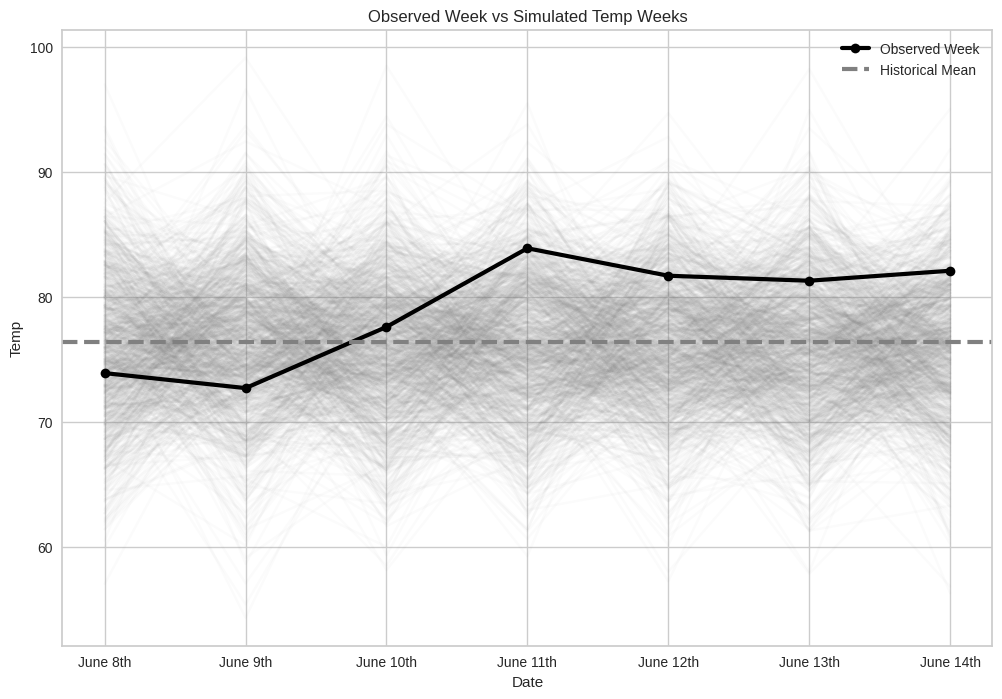

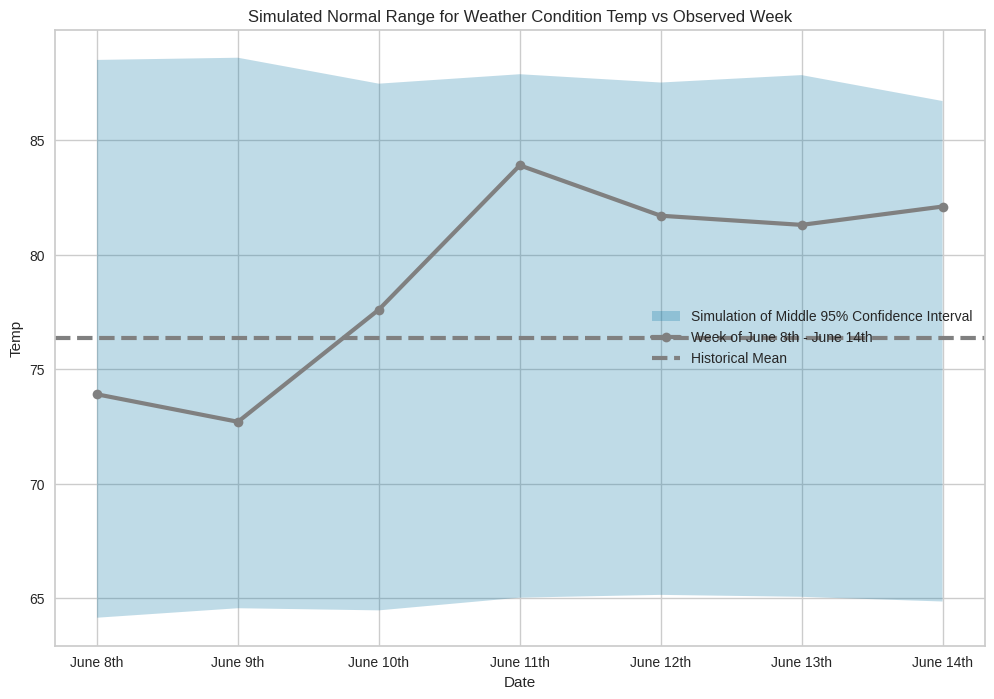

In [27]:
seed = random.randint(1, 422)
sim_days = 1000
np.random.seed(seed)



def display_simulation(label:str, simulations, mean, standard, alpha:float):
    # Simulates 1000 weeks. 7 days per week -> 7,000 labels (i.e, temps, precip, humidity. etc)
    sim = np.random.normal(loc=mu, scale=sigma, size=(sim_days, len(seven_day_forecast[label])))

    dates = [
        "June 8th",
        "June 9th",
        "June 10th",
        "June 11th",
        "June 12th",
        "June 13th",
        "June 14th"
    ]
    plt.figure(figsize=(12, 8))
    for week in sim:
        plt.plot(
            dates,
            week,
            color="grey",
            alpha= .03
        )
    
    plt.plot(dates, seven_day_forecast[label], color="black", linewidth=3, marker="o", label="Observed Week")
    plt.xlabel("Date")
    plt.ylabel(label)
    plt.title(f"Observed Week vs Simulated {label} Weeks")
    plt.axhline(mean, color = 'grey', linestyle="--", linewidth=3, label="Historical Mean")
    plt.legend()
    plt.show()

    interval = 100 - alpha
    plt.figure(figsize=(12, 8))
    # Simulating a confidence interval 100% - alpha = ....%.
    # We must split that on both ends so alpha / 2% = ....%
    # (alpha / 2) |CI| (alpha / 2)
    plt.fill_between(dates,
                     np.percentile(sim, alpha / 2, axis=0), # Starting point
                     np.percentile(sim, 100 - (alpha / 2), axis=0), # Ending point
                     alpha=.25, # How shaded in the region is 
                     label=f"Simulation of Middle {interval}% Confidence Interval"
    )

    plt.plot(dates,
             seven_day_forecast[label],
             color='grey',
             linewidth=3,
             marker='o',
             label="Week of June 8th - June 14th"
             
    )
    
    plt.xlabel("Date")
    plt.ylabel(label)
    plt.title(f"Simulated Normal Range for Weather Condition {label} vs Observed Week")
    plt.axhline(mean, color = 'grey', linestyle="--", linewidth=3, label="Historical Mean")
    plt.legend()
    plt.show()

temp_mean = combined_df["Temp"].mean()
temp_std = combined_df["Temp"].std()

alpha = 5
# 95 Confidence Interval
display_simulation("Temp", sim_days, temp_mean, temp_std, alpha)



## Conclusion:
Having performed the following tests and simulation:
- Two Tailed T Test
- Left T Test
- Two Tailed Z Test
- Two Sample T Test
- Correlation Test
- Data Simulation

### The Main Characteristics of Our Dataset:
These would be the features in our API call.
    
- Humidity
- Temperature
- Max Temperature
- Min Temperature
- Feels Like
- Precipitation
- Windspeed

#### Summary:
Based on the Z and T tests, we've determined that usually there is no significant evidence that the individual features differ when comparing the week of sample data to historical June.
The reason why we chose Z and T tests, but primarily focused on the T tests is that the standard deviation was unknown as even though we chose three years worth of Junes, that is still a sample of the total June's in history. 
We still included a Two Tailed Z test as weather is volatile as we wanted to approximate the true population standard deviation with historical data.
We did this because n is greater than 30 where n = 90 records of historical data (CLT). 

Based on the fields we tested, the only fields with strong correlation to each other were Temperature and Feels Like with a correlation=0.981. We had theorized there would have been stronger correlations with Temperature and other fields such as Humidity, but discovered the there was a very weak negative correlation between the two at a correlation=-0.107. However, we found an interesting moderately strong positive correlation between Humidty and Percipitation coming in at correlation=0.517, but expected this value to be higher.

## Part 3: Machine Learning

We used K-Means clustering to group historical June weather into similar weather patterns based on temperature, humidity, precipitation, and windspeed. The weather features were standardized before applying PCA, which reduced the data to two dimensions for visualization. Using the Elbow Method, we selected three clusters for the final model. The observed week of June 8–14, 2026 was then classified into these clusters to determine which historical weather patterns it resembled most. Finally, the average weather conditions of each cluster were examined to interpret the characteristics of the different June weather patterns.

### Principal Component Analysis

PCA was used to reduce the dimensionality of the weather data while preserving as much of the original variability as possible. This allows the historical weather observations to be visualized in two dimensions before clustering.

In [28]:
weather_features = ["Temp", "Humidity", "Precip", "Windspeed"]

historical_features = combined_df[weather_features].dropna()

#standardize
scaler = StandardScaler()
historical_scaled = scaler.fit_transform(historical_features)

pca = PCA(n_components=2)
historical_pca = pca.fit_transform(historical_scaled)

print("Explained variance ratio:", pca.explained_variance_ratio_)
print("Total explained variance:", pca.explained_variance_ratio_.sum())

Explained variance ratio: [0.38973909 0.27995423]
Total explained variance: 0.6696933228102515


### Determining the Number of Clusters

The Elbow Method was used to determine an appropriate number of clusters for the historical weather data.

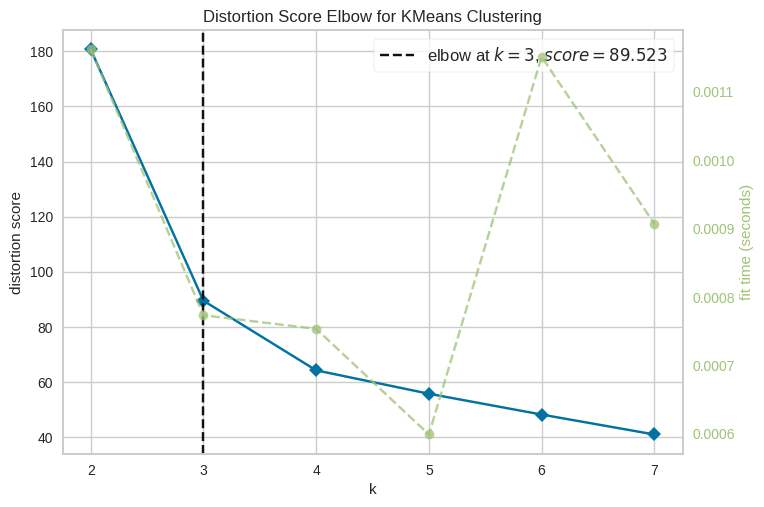

<Axes: title={'center': 'Distortion Score Elbow for KMeans Clustering'}, xlabel='k', ylabel='distortion score'>

In [29]:
model = KMeans(random_state=42)

visualizer = KElbowVisualizer(model, k=(2,8))

visualizer.fit(historical_pca)
visualizer.show()

The Elbow Method indicates that three clusters provide a good balance between minimizing within-cluster variation and avoiding unnecessary complexity. Therefore, k = 3 was selected for the K-Means model.

### Historical Weather Clusters

After selecting three clusters, K-Means was applied to the historical weather data projected into PCA space.

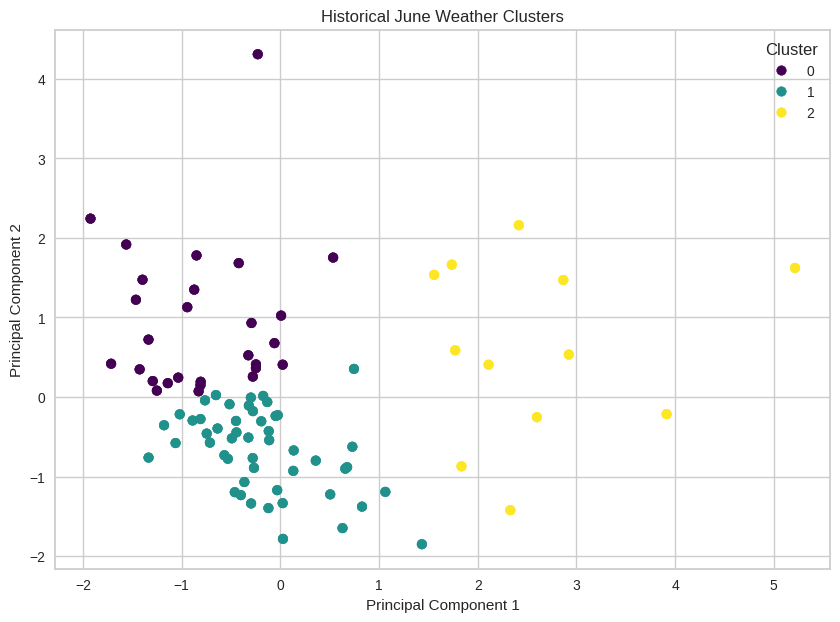

In [31]:
k_cluster = 3

kmeans = KMeans(n_clusters=k_cluster, random_state=42)
historical_labels = kmeans.fit_predict(historical_pca)

plt.figure(figsize=(10,7))

plt.scatter(historical_pca[:,0],historical_pca[:, 1], c=historical_labels, cmap="viridis")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("Historical June Weather Clusters")

# Organize dots based on cliuster
scatter = plt.scatter(
    historical_pca[:,0],
    historical_pca[:,1],
    c=historical_labels,
    cmap="viridis"
)

plt.legend(*scatter.legend_elements(), title="Cluster")

plt.show()

Each point in the figure represents one historical June weather observation (one day) from 2023–2025. Since the original weather data contains four variables (temperature, humidity, precipitation, and windspeed), Principal Component Analysis (PCA) was used to reduce the data to two principal components. These principal components capture most of the variation in the original dataset while allowing the observations to be visualized in two dimensions.

The colors indicate the cluster assigned by the K-Means algorithm. Days that appear close together on the graph have similar overall weather conditions, while points that are farther apart represent more distinct weather patterns. The three visible groups indicate that the historical June weather naturally separates into three common weather patterns.

Although the principal components do not correspond to individual weather variables, they are combinations of temperature, humidity, precipitation, and windspeed that preserve the overall structure of the data. This makes it easier to visualize similarities between historical weather observations while reducing the complexity of the dataset.

### Classifying the Observed Week

The same scaler and PCA transformation were applied to the observed week before classifying each day into one of the historical weather clusters.

In [14]:
week_features = seven_day_forecast[weather_features].dropna()
week_scaled = scaler.transform(week_features)
week_pca = pca.transform(week_scaled)
week_labels = kmeans.predict(week_pca)
week_results = seven_day_forecast.loc[week_features.index].copy()
week_results["Cluster"] = week_labels
display(week_results[["Datetime"] + weather_features + ["Cluster"]])

,Datetime,Temp,Humidity,Precip,Windspeed,Cluster
1,2026-06-08,73.9,58.7,0.000,12.0,1
2,2026-06-09,72.7,55.1,0.000,12.3,1
3,2026-06-10,77.6,76.1,0.098,13.5,1
4,2026-06-11,83.9,69.3,0.004,13.1,1
5,2026-06-12,81.7,71.9,0.111,19.7,0
6,2026-06-13,81.3,55.6,0.000,13.4,1
7,2026-06-14,82.1,63.7,0.010,22.1,0


The table below shows the weather conditions for each day in the observed week (June 8–14, 2026) along with the cluster assigned by the trained K-Means model. Before classification, the observed weather data was standardized using the same scaler applied to the historical data and projected into the same PCA space. Each day was then assigned to the historical weather cluster whose centroid was closest to its weather conditions.

The results indicate that five of the seven observed days were assigned to **Cluster 1**, while the remaining two days were assigned to **Cluster 0**. No days were classified as **Cluster 2**, suggesting that the observed week was generally characterized by the weather patterns represented by Clusters 0 and 1, rather than the cooler and more humid conditions associated with Cluster 2.

### Cluster Characteristics

The table below shows the average weather conditions represented by each cluster.

In [36]:
cluster_summary = historical_features.copy()
cluster_summary["Cluster"] = historical_labels
display(cluster_summary.groupby("Cluster").mean().round(3))

,Temp,Humidity,Precip,Windspeed
Cluster,,,,
0,79.014,55.900,0.030,18.196
1,75.856,63.108,0.012,12.342
2,72.258,85.008,0.489,15.625


The table above summarizes the average weather conditions represented by each cluster. These values correspond to the centroid of each cluster and represent the typical temperature, humidity, precipitation, and windspeed of the historical June days assigned to that group.

- **Cluster 0** represents relatively **hot, dry, and windy** weather, with the highest average temperature (79.0°F) and windspeed (18.2 mph), while experiencing very little precipitation.

- **Cluster 1** represents **warm, relatively dry, and calm** weather. It has slightly lower temperatures than Cluster 0, moderate humidity, the lowest average windspeed, and minimal precipitation. Most days from the observed week were assigned to this cluster.

- **Cluster 2** represents **cooler, humid, and rainy** weather. It has the lowest average temperature (72.3°F), the highest humidity (85.0%), and substantially more precipitation than the other two clusters, making it the wettest historical weather pattern identified by the model.

### Historical Weather Compared to the Observed Week

The following figure overlays the observed week onto the historical clusters. Each red X represents one day from June 8–14, 2026.

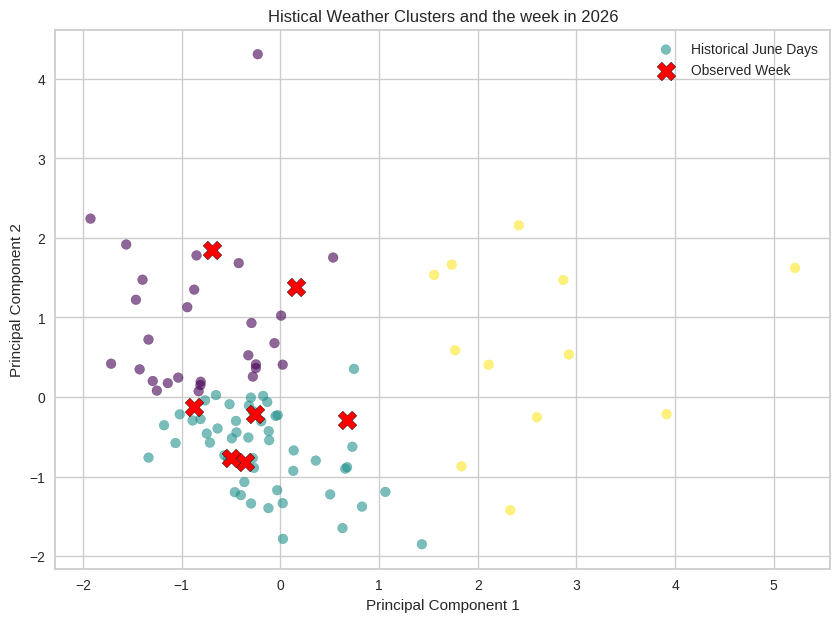

In [18]:
plt.figure(figsize=(10,7))
plt.scatter(historical_pca[:,0], historical_pca[:,1], c=historical_labels, cmap="viridis", alpha=0.6, label="Historical June Days")
plt.scatter(week_pca[:,0], week_pca[:,1], marker="X", s=180, c="red", edgecolors="black",label="Observed Week")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("Histical Weather Clusters and the week in 2026")
plt.legend()
plt.show()

The figure below compares the observed week of June 8–14, 2026 **(red X markers)** to the historical June weather observations (colored circles). The historical observations are projected into two principal components using PCA and grouped into **three clusters** using the K-Means algorithm. Each colored circle represents one historical June day, while each **red X** represents one day from the observed week.

The observed week falls primarily within the regions occupied by **Clusters 0 and 1**, indicating that most of the observed days closely resemble common historical June weather patterns. None of the observed days were located near the region associated with **Cluster 2**, which represents cooler, more humid, and wetter weather conditions. These results suggest that the observed week is generally consistent with the warmer and drier historical weather patterns found in the June dataset.

# Final Insights and Conclusions

This project combined statistical analysis and machine learning techniques to determine whether the week of June 8–14, 2026 was representative of historical June weather in Washington, D.C. Statistical analyses, including Z-scores, hypothesis testing, and simulations, were used to compare the observed week to historical weather conditions. Principal Component Analysis (PCA) reduced the dimensionality of the weather data, while K-Means clustering identified three distinct historical weather patterns.

The observed week was primarily classified into Clusters 0 and 1, indicating that most days closely resembled common historical June weather patterns. No observed days were assigned to Cluster 2, which represented cooler, wetter, and more humid conditions. Taken together, these results suggest that the observed week was generally consistent with the warmer and drier weather patterns commonly observed during June.

Although this analysis provides useful insights, it is limited to three years of historical June data and a small set of weather variables. Future work could incorporate additional years of historical observations, more weather features, and alternative clustering techniques to provide a more comprehensive analysis of seasonal weather patterns.